# Разведочный анализ данных. Исследование и визуализация данных.
#
 ## 1) Текстовое описание набора данных
В качестве набора данных мы будем использовать набор данных **Wine** из библиотеки `scikit-learn`.

Этот датасет является классическим примером для задач многоклассовой классификации. Он содержит результаты химического анализа вин, выращенных в одном регионе Италии, но произведенных тремя разными культиваторами (винодельнями). Задача состоит в том, чтобы на основе химического состава вина определить его происхождение (класс).

Датасет представляет собой готовый к использованию массив данных, не содержащий пропусков, что делает его идеальным для первичного знакомства с анализом данных.

Данные включают 13 признаков, описывающих химический состав вина, и целевую переменную — класс вина (1, 2 или 3).

 **Описание признаков:**

 *   **target:** Класс вина (целевая переменная: 1, 2, 3)
 *   **alcohol:** Содержание алкоголя.
 *   **malic_acid:** Яблочная кислота.
 *   **ash:** Зольность.
 *   **alcalinity_of_ash:** Щелочность золы.
 *   **magnesium:** Магний.
 *   **total_phenols:** Общее количество фенолов.
 *   **flavanoids:** Флавоноиды.
 *   **nonflavanoid_phenols:** Нефлаваноидные фенолы.
 *   **proanthocyanins:** Проантоцианидины.
 *   **color_intensity:** Интенсивность цвета.
 *   **hue:** Оттенок.
 *   **od280/od315_of_diluted_wines:** Оптическая плотность (показатель, связанный с концентрацией веществ).
 *   **proline:** Пролин (аминокислота).

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from IPython.display import display

# Настройка стиля для графиков
%matplotlib inline
sns.set(style="ticks")

# Загрузим датасет Wine
wine_data = load_wine()

# Создание DataFrame с признаками
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

# Добавление целевой переменной 'target'
df['target'] = wine_data.target

# СОЗДАЁМ КОЛОНКУ С НАЗВАНИЯМИ КЛАССОВ (исправление)
df['class_name'] = df['target'].map({i: name for i, name in enumerate(wine_data.target_names)})

# 2) Основные характеристики датасета


In [19]:
# 1. Размер датасета
print('Размер DataFrame:', df.shape)

# 2. Первые 5 записей
print('\nПервые 5 записей:')
display(df.head())

# 3. Информация о данных и пропусках
print('\nИнформация о данных:')
df.info()

print('\nКоличество пропусков по столбцам:')
print(df.isnull().sum())

# 4. Описательная статистика
print('\nОписательная статистика:')
display(df.describe())

# 5. Распределение целевой переменной
print('\nРаспределение классов:')
print(df['class_name'].value_counts())

Размер DataFrame: (178, 15)

Первые 5 записей:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



Распределение классов:
class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


**Выводы по разделу:**
*   Датасет содержит **178** образцов вин.
 *   Каждое вино описано **13** химическими признаками.
 *   Целевая переменная `target` имеет 3 уникальных значения (классы вин: 0, 1, 2).
 *   В данных **нет пропусков**, все признаки представлены вещественными числами (`float64`), а целевая переменная — целым числом (`int64`).
 *   Статистики `describe()` показывают, что признаки имеют разные масштабы. Например, `alcohol` варьируется от ~11 до ~15, а `proline` — от 278 до 1680. Это важное наблюдение для дальнейшей подготовки данных.

 ## 3) Визуальное исследование датасета

Для визуального исследования могут быть использованы различные виды диаграмм, мы построим только некоторые варианты диаграмм, которые используются достаточно часто.

[Диаграмма рассеяния (Scatter Plot)](https://en.wikipedia.org/wiki/Scatter_plot)

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости.

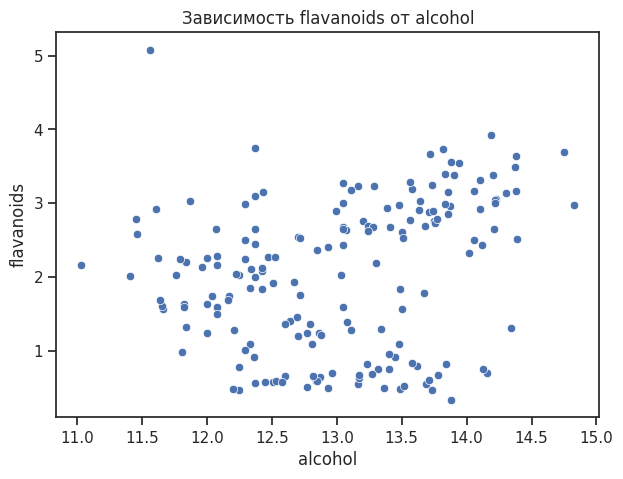

/n На графике видно, что точки образуют несколько кластеров, но общая зависимость прослеживается слабо.


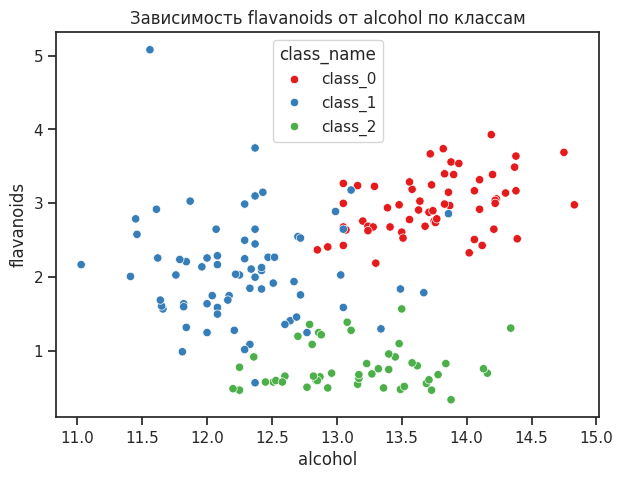

Наблюдение: точки разных классов образуют относительно обособленные кластеры. Это говорит о том, что комбинация этих двух признаков уже неплохо разделяет вина по сортам.


In [22]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(ax=ax, x='alcohol', y='flavanoids', data=df)
ax.set_title('Зависимость flavanoids от alcohol')
plt.show()
print("/n На графике видно, что точки образуют несколько кластеров, но общая зависимость прослеживается слабо.")

# Посмотрим, как на эту зависимость влияет целевой признак (класс вина)
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(ax=ax, x='alcohol', y='flavanoids', data=df, hue='class_name', palette='Set1')
ax.set_title('Зависимость flavanoids от alcohol по классам')
plt.show()
print("Наблюдение: точки разных классов образуют относительно обособленные кластеры. Это говорит о том, что комбинация этих двух признаков уже неплохо разделяет вина по сортам.")


[Гистограмма (Histogram)](https://en.wikipedia.org/wiki/Histogram)

Позволяет оценить плотность вероятности распределения данных.

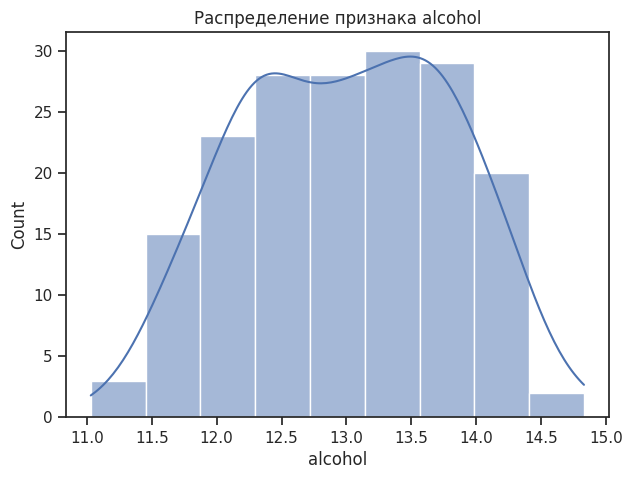

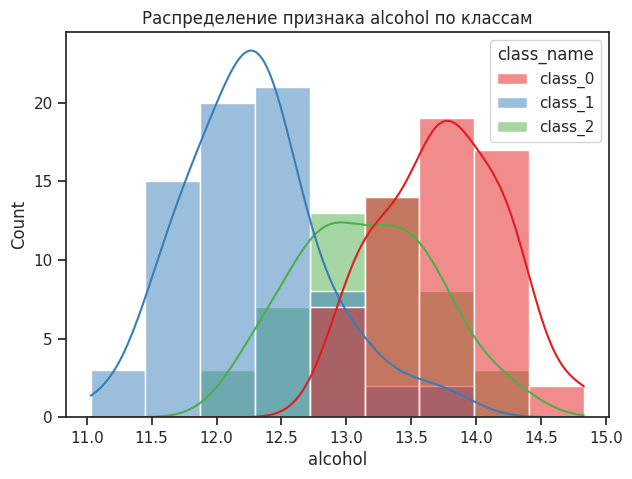

Гистограмма наглядно демонстрирует, что распределение содержания алкоголя различается для вин разных классов. Класс 0 имеет самое высокое содержание алкоголя, а класс 1 — самое низкое.


In [24]:
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=df, x='alcohol', kde=True, ax=ax)
ax.set_title('Распределение признака alcohol')
plt.show()

# Распределение alcohol по классам
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=df, x='alcohol', hue='class_name', kde=True, palette='Set1', ax=ax)
ax.set_title('Распределение признака alcohol по классам')
plt.show()
print("Гистограмма наглядно демонстрирует, что распределение содержания алкоголя различается для вин разных классов. Класс 0 имеет самое высокое содержание алкоголя, а класс 1 — самое низкое.")

Jointplot

Комбинация гистограмм и диаграмм рассеивания.

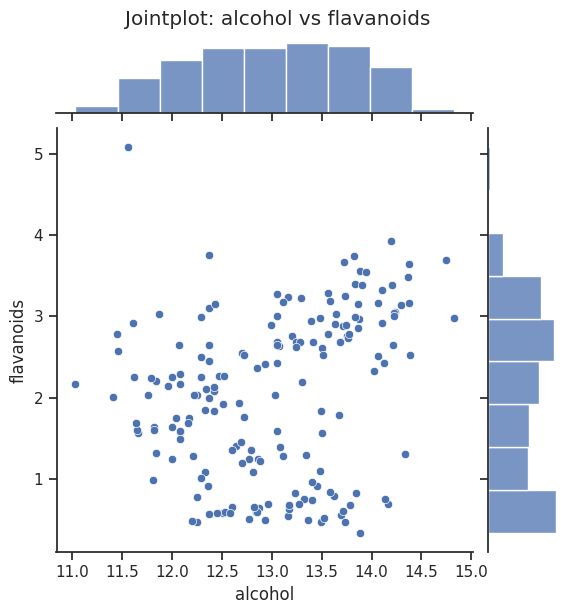

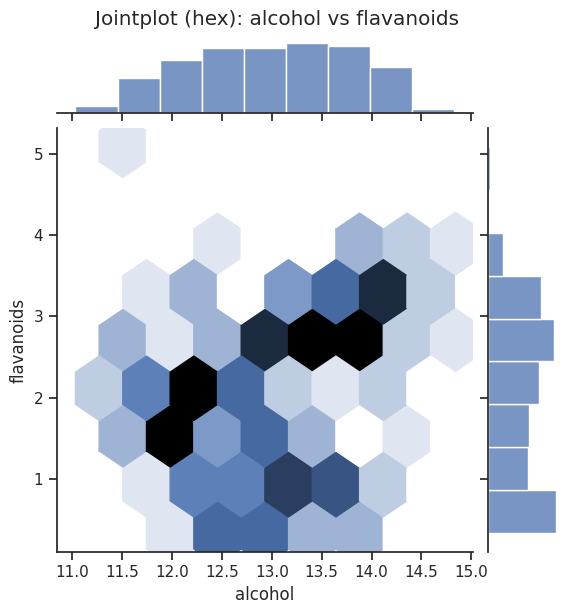

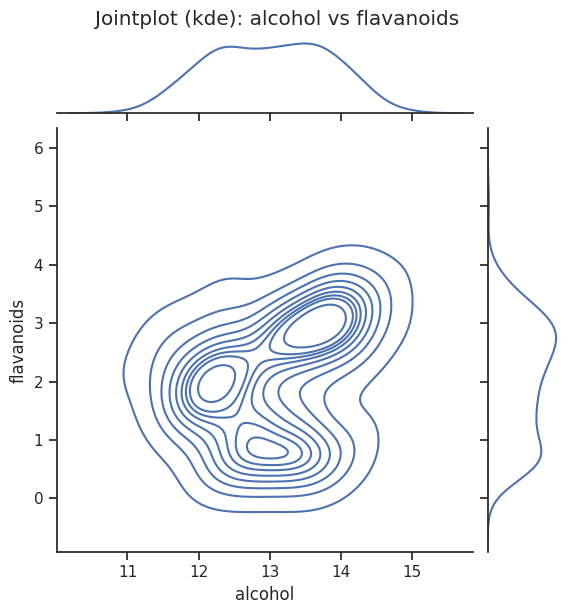

In [25]:
sns.jointplot(x='alcohol', y='flavanoids', data=df)
plt.suptitle('Jointplot: alcohol vs flavanoids', y=1.02)
plt.show()

sns.jointplot(x='alcohol', y='flavanoids', data=df, kind="hex")
plt.suptitle('Jointplot (hex): alcohol vs flavanoids', y=1.02)
plt.show()

sns.jointplot(x='alcohol', y='flavanoids', data=df, kind="kde")
plt.suptitle('Jointplot (kde): alcohol vs flavanoids', y=1.02)
plt.show()

"Парные диаграммы" (Pairplot)

 Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

 Выводится матрица графиков. На пересечении строки и столбца, которые соответствуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.


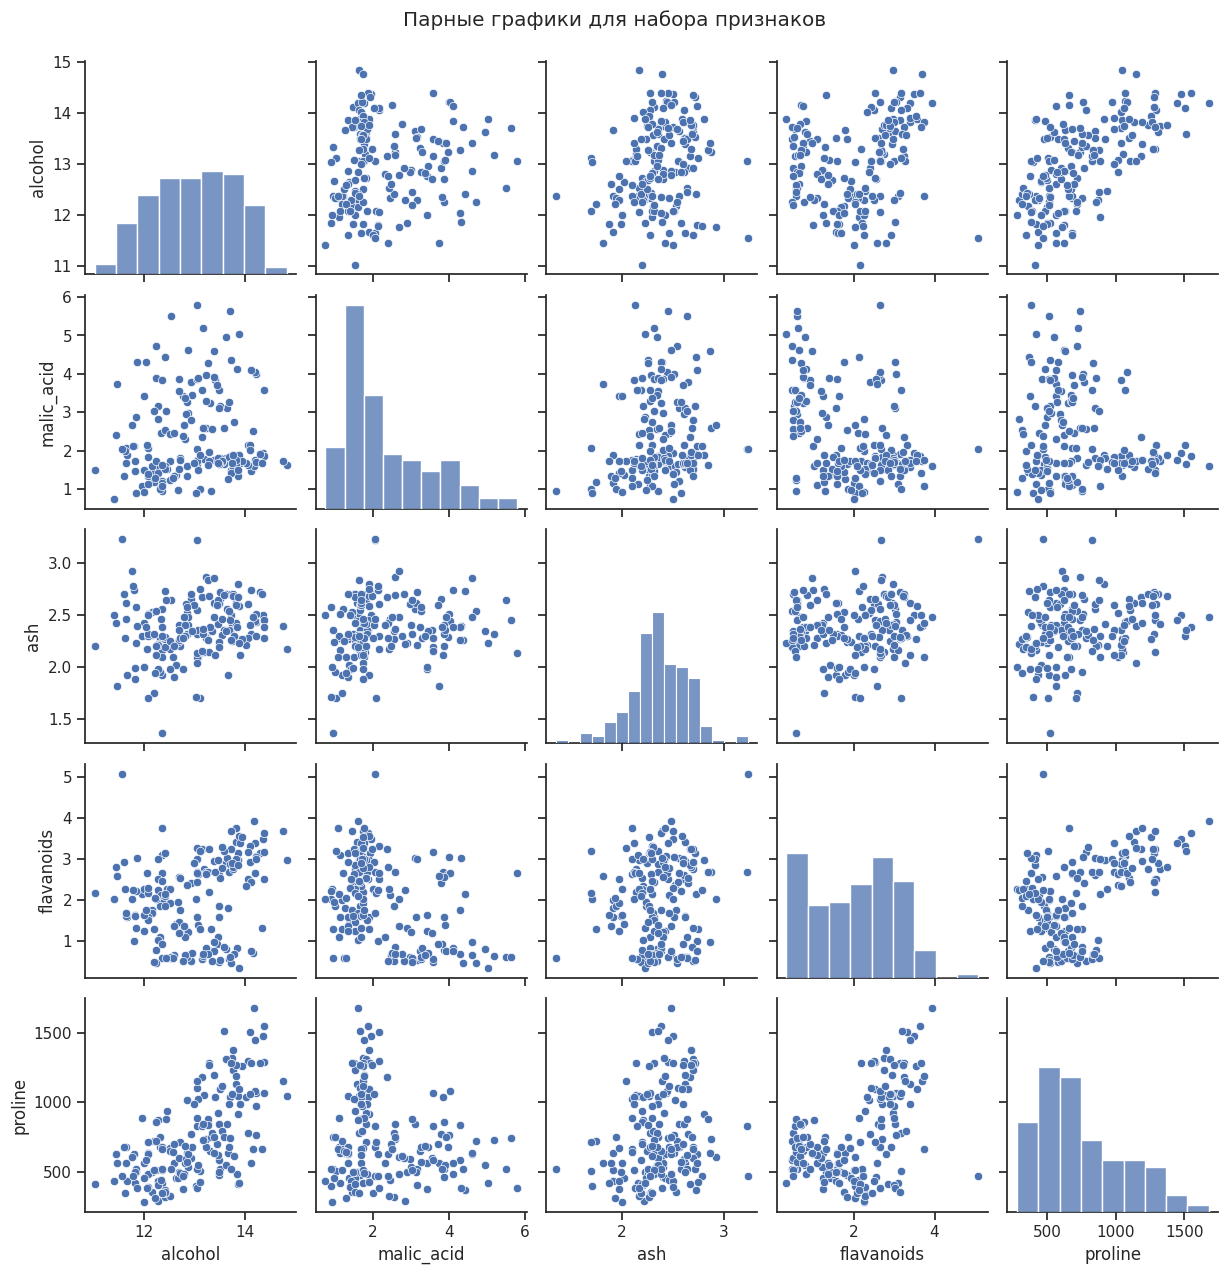

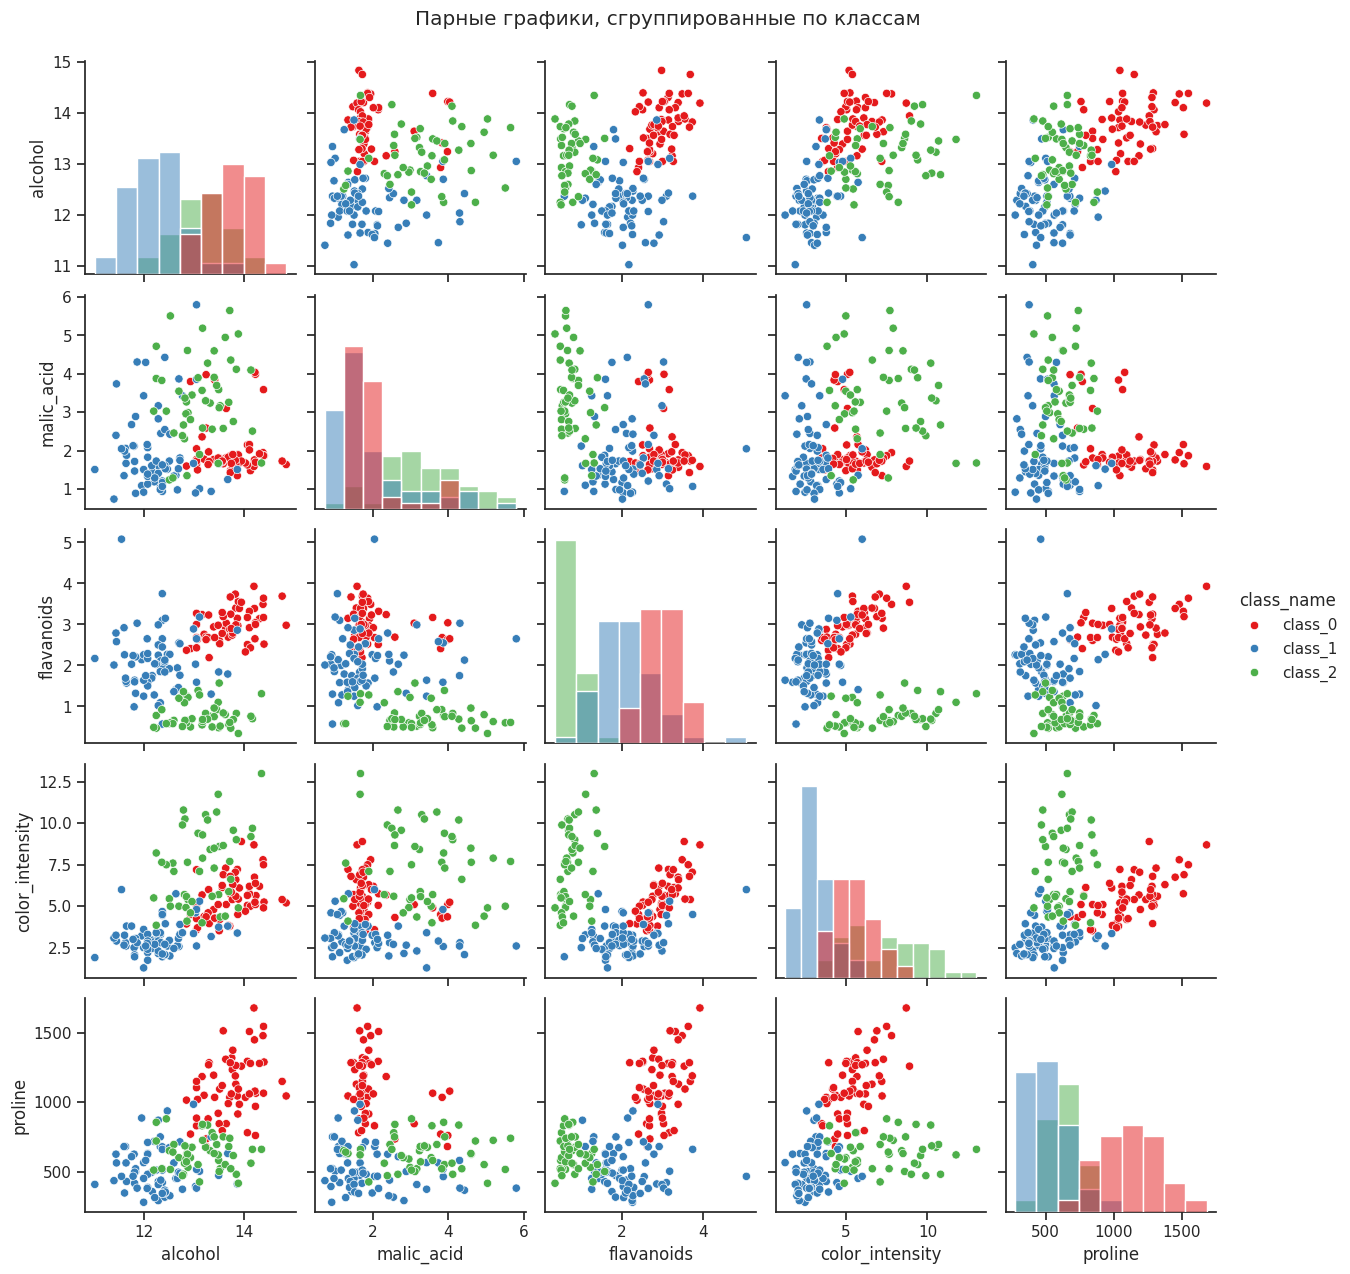

Pairplot — очень мощный инструмент. На нем хорошо видно, какие пары признаков лучше всего разделяют классы.


In [26]:
# Выберем несколько ключевых признаков для визуализации, чтобы график не был перегружен
selected_features = ['alcohol', 'malic_acid', 'ash', 'flavanoids', 'proline']
sns.pairplot(df[selected_features])
plt.suptitle('Парные графики для набора признаков', y=1.02)
plt.show()

# Сгруппированные по целевому признаку
selected_features_for_hue = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity', 'proline', 'class_name']
sns.pairplot(df[selected_features_for_hue], hue='class_name', palette='Set1', diag_kind='hist')
plt.suptitle('Парные графики, сгруппированные по классам', y=1.02)
plt.show()
print("Pairplot — очень мощный инструмент. На нем хорошо видно, какие пары признаков лучше всего разделяют классы.")

Ящик с усами (Box Plot)

Отображает одномерное распределение вероятности.

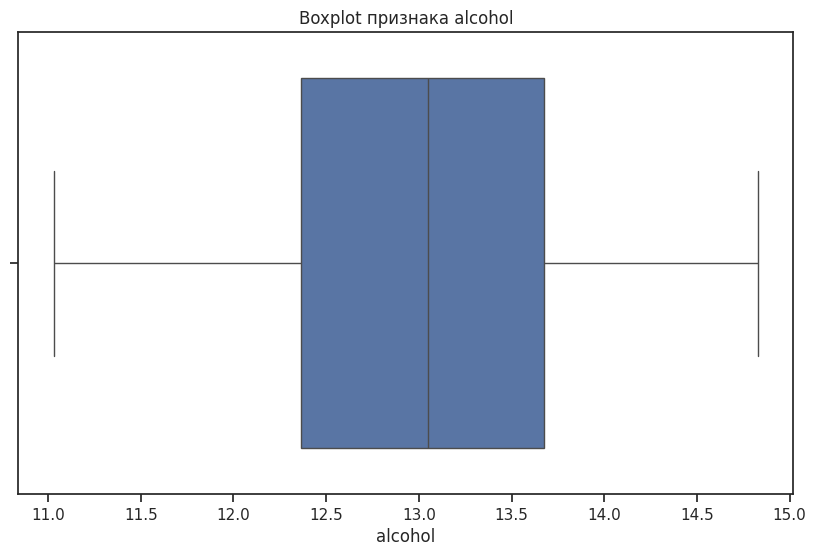

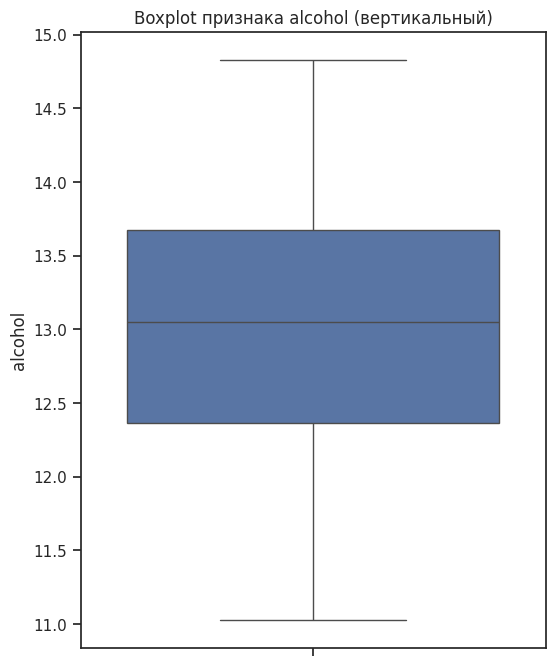

/tmp/ipykernel_378/3827116757.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class_name', y='alcohol', data=df, palette='Set1', ax=ax)


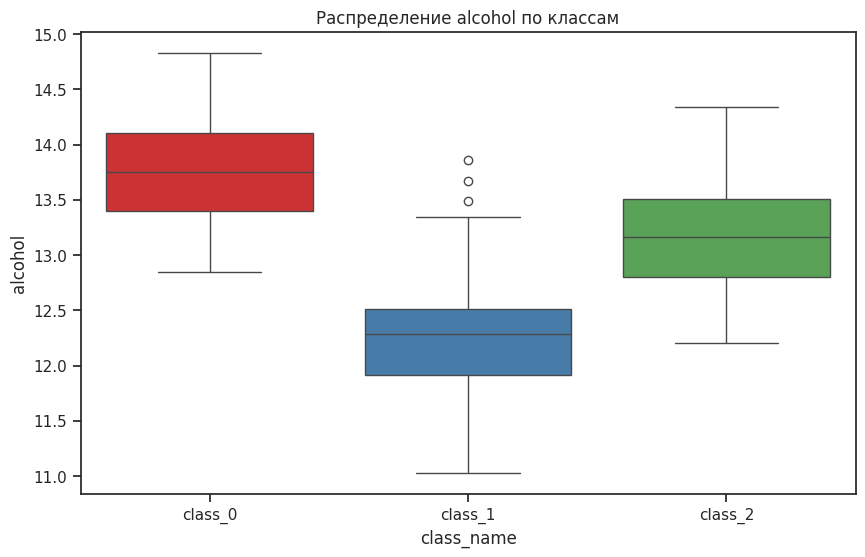

Наблюдение: Медианное значение алкоголя сильно различается между классами


In [28]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(x=df['alcohol'], ax=ax)
ax.set_title('Boxplot признака alcohol')
plt.show()

# По вертикали
fig, ax = plt.subplots(figsize=(6,8))
sns.boxplot(y=df['alcohol'], ax=ax)
ax.set_title('Boxplot признака alcohol (вертикальный)')
plt.show()

# Распределение параметра alcohol, сгруппированное по class_name
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(x='class_name', y='alcohol', data=df, palette='Set1', ax=ax)
ax.set_title('Распределение alcohol по классам')
plt.show()
print("Наблюдение: Медианное значение алкоголя сильно различается между классами")

Violin plot

Похоже на предыдущую диаграмму, но по краям отображаются распределения плотности.

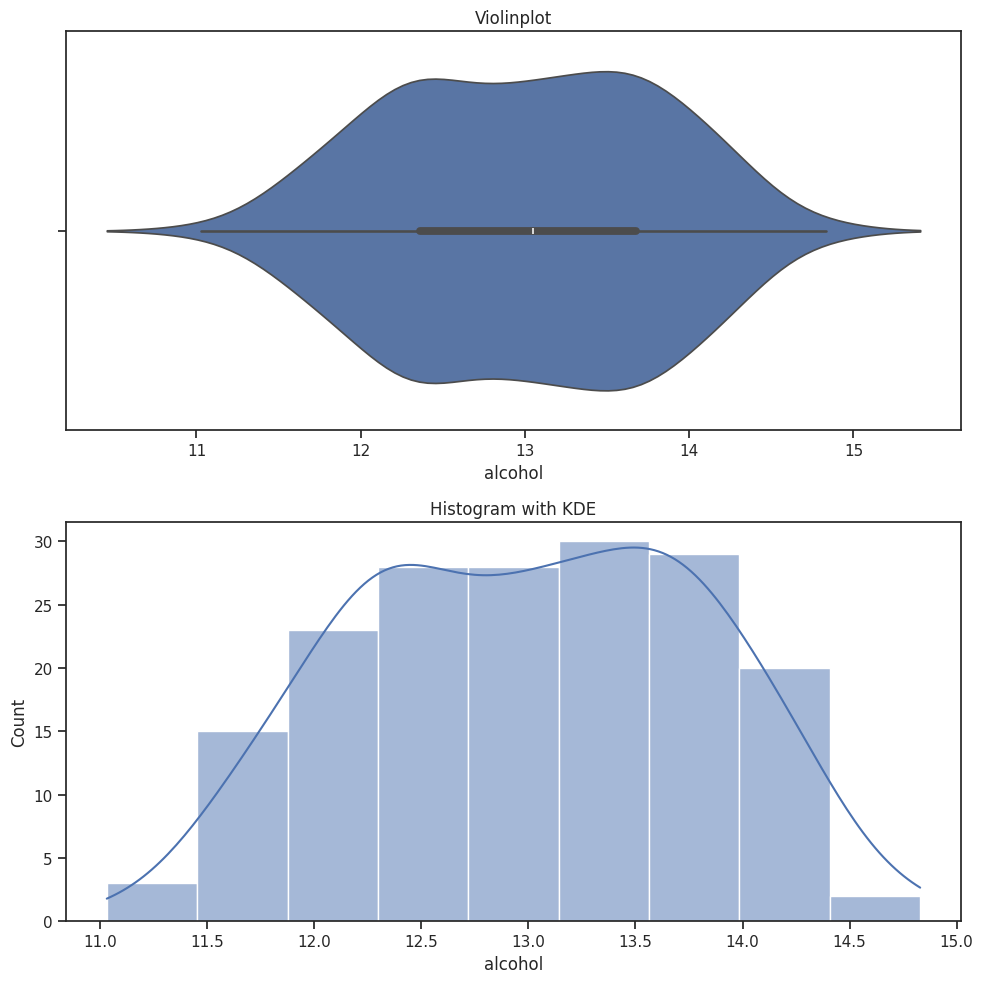

Из приведенных графиков видно, что violinplot действительно показывает распределение плотности.


/tmp/ipykernel_378/3696941311.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class_name', y='alcohol', data=df, palette='Set1', ax=ax)


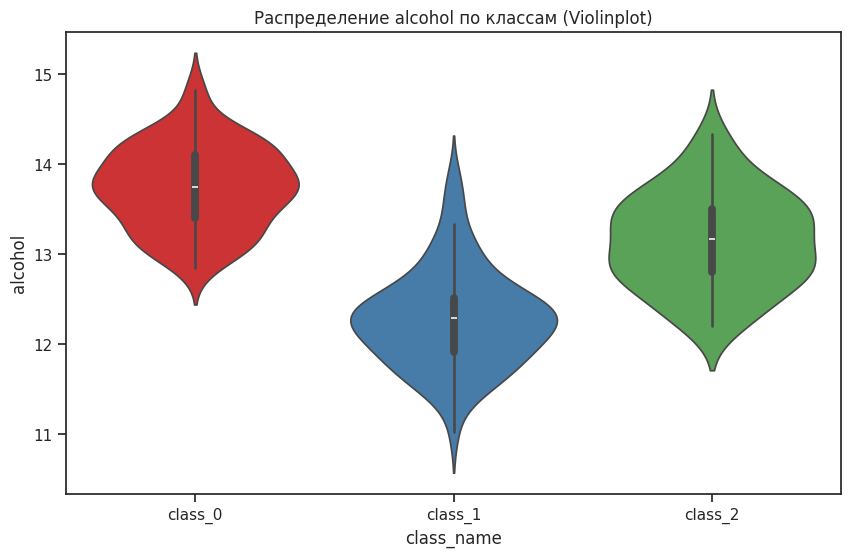

In [29]:
# Сравнение violinplot и гистограммы
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=df['alcohol'])
sns.histplot(data=df, x='alcohol', kde=True, ax=ax[1])
ax[0].set_title('Violinplot')
ax[1].set_title('Histogram with KDE')
plt.tight_layout()
plt.show()
print("Из приведенных графиков видно, что violinplot действительно показывает распределение плотности.")

# Распределение параметра alcohol, сгруппированное по class_name
fig, ax = plt.subplots(figsize=(10,6))
sns.violinplot(x='class_name', y='alcohol', data=df, palette='Set1', ax=ax)
ax.set_title('Распределение alcohol по классам (Violinplot)')
plt.show()

#  4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:

 1.  Понять, какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка `target`). Именно эти признаки будут наиболее информативными для моделей машинного обучения.
 2.  Понять, какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, плохо влияют на качество моделей.

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print('Корреляционная матрица:')
display(correlation_matrix)

# Различные методы расчета корреляции
print("Метод Пирсона:")
display(df.corr(method='pearson', numeric_only=True))

print("\nМетод Кендалла:")
display(df.corr(method='kendall', numeric_only=True))

print("\nМетод Спирмена:")
display(df.corr(method='spearman', numeric_only=True))

* Целевой признак `target` наиболее сильно коррелирует с признаками `flavanoids` (-0.85), `od280/od315_of_diluted_wines` (-0.79) и `total_phenols` (-0.72).
*   Признаки `flavanoids` и `total_phenols` очень сильно коррелируют между собой (0.86). Поэтому из этих признаков в модели можно оставлять только один.

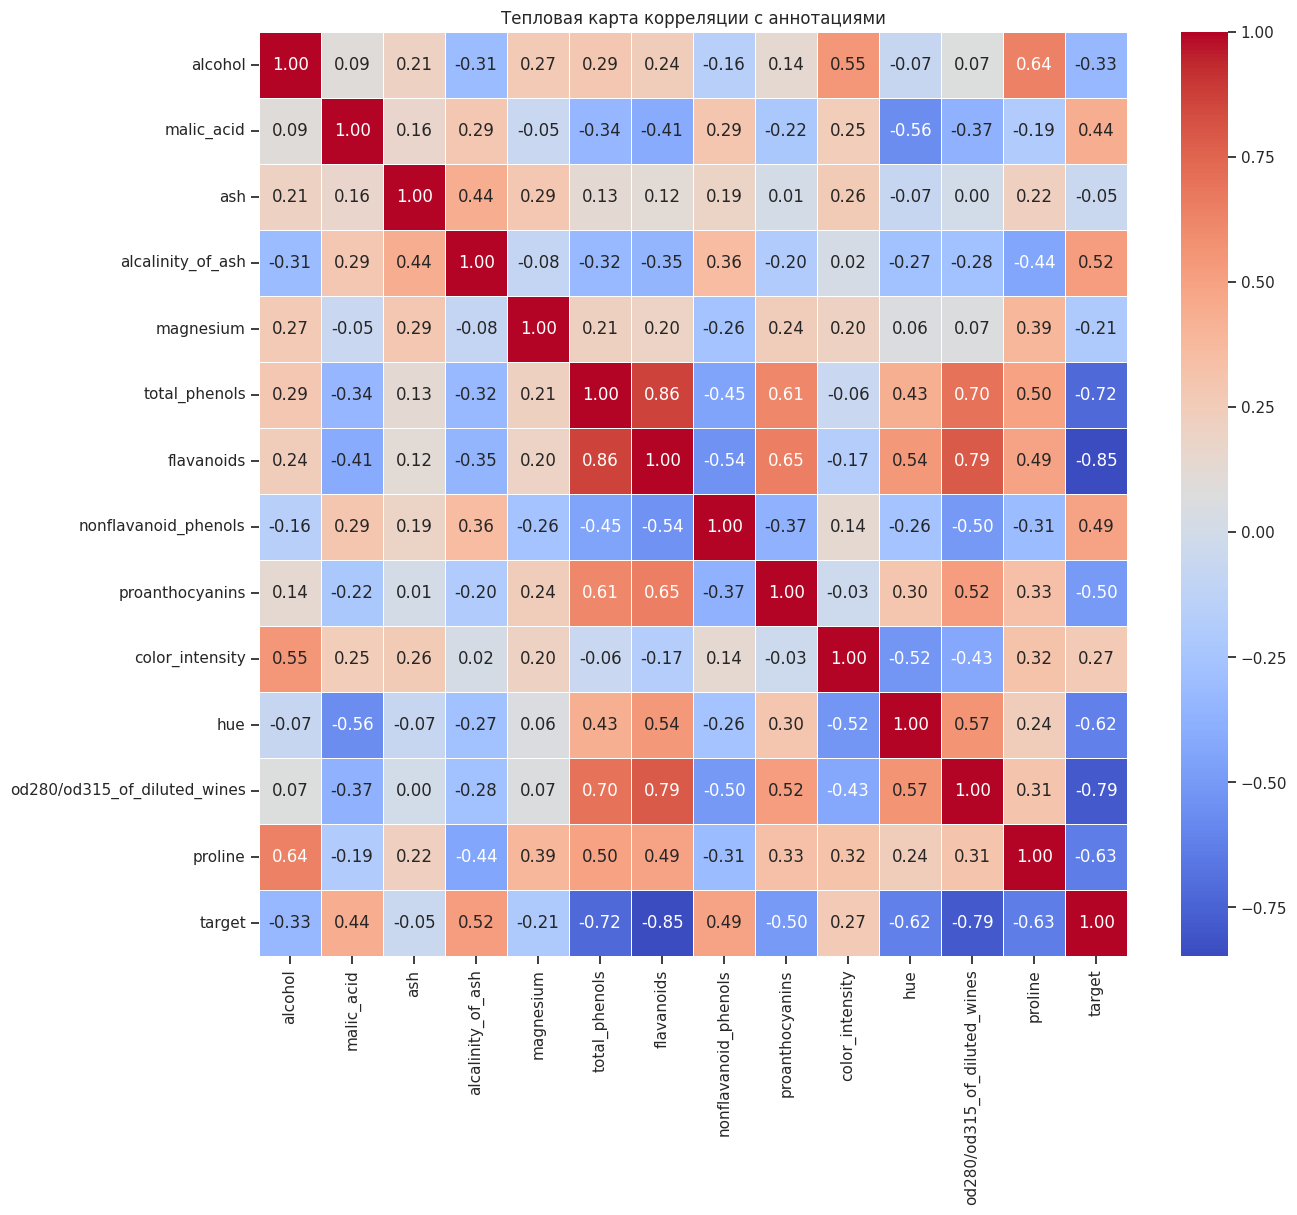

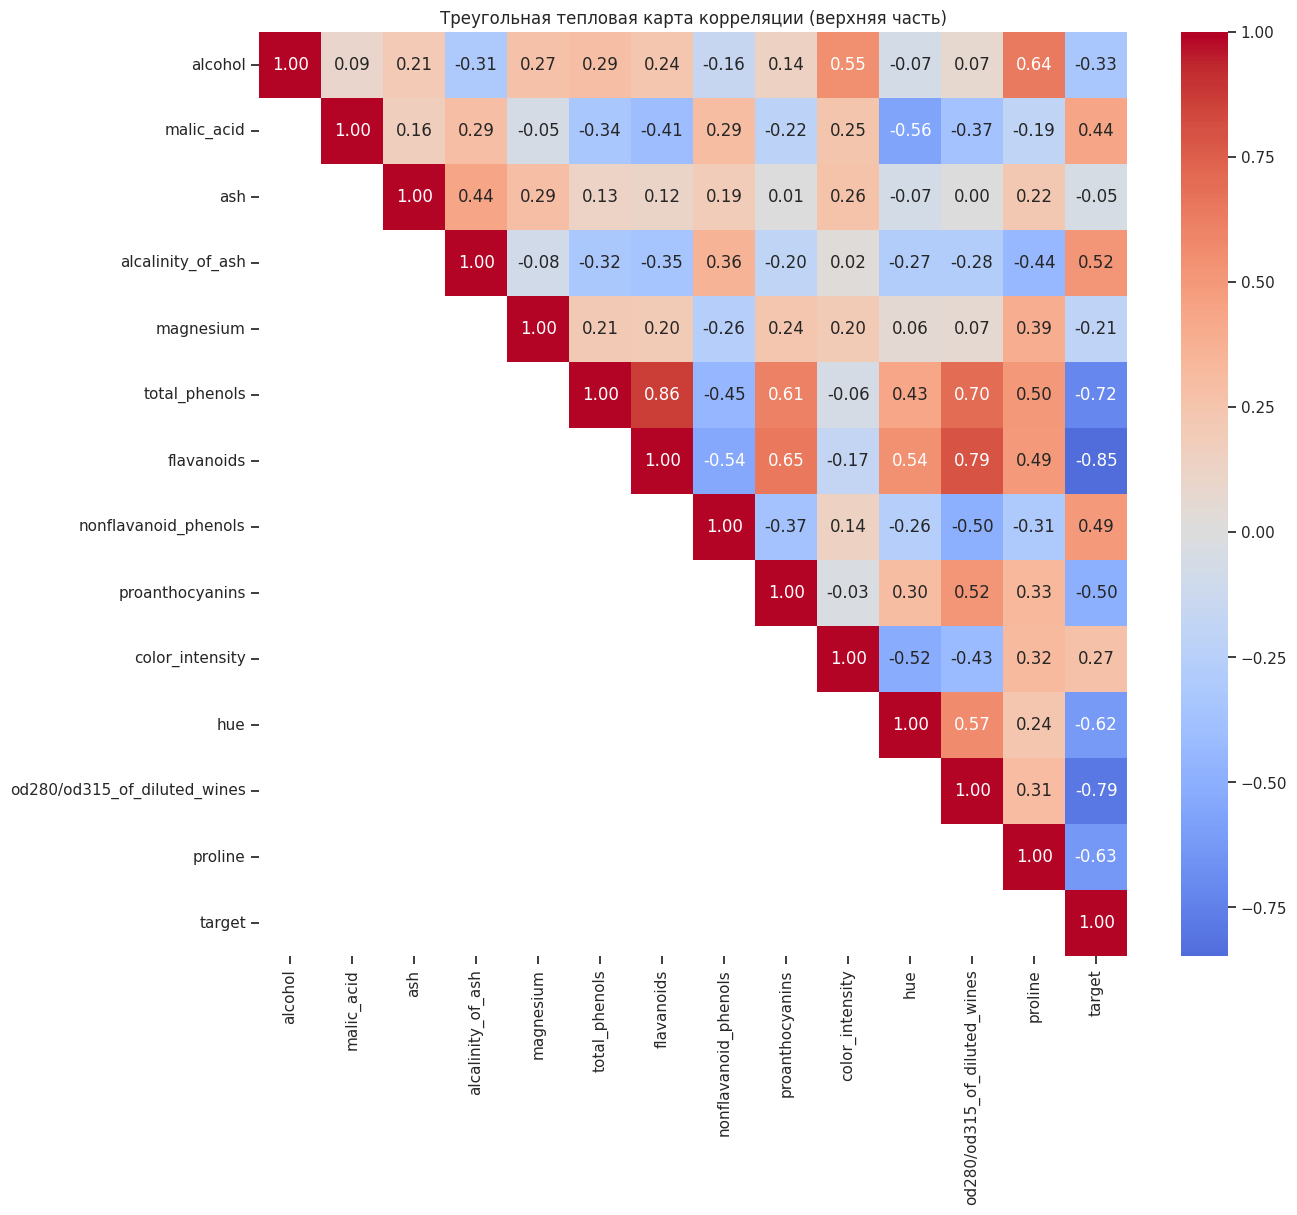

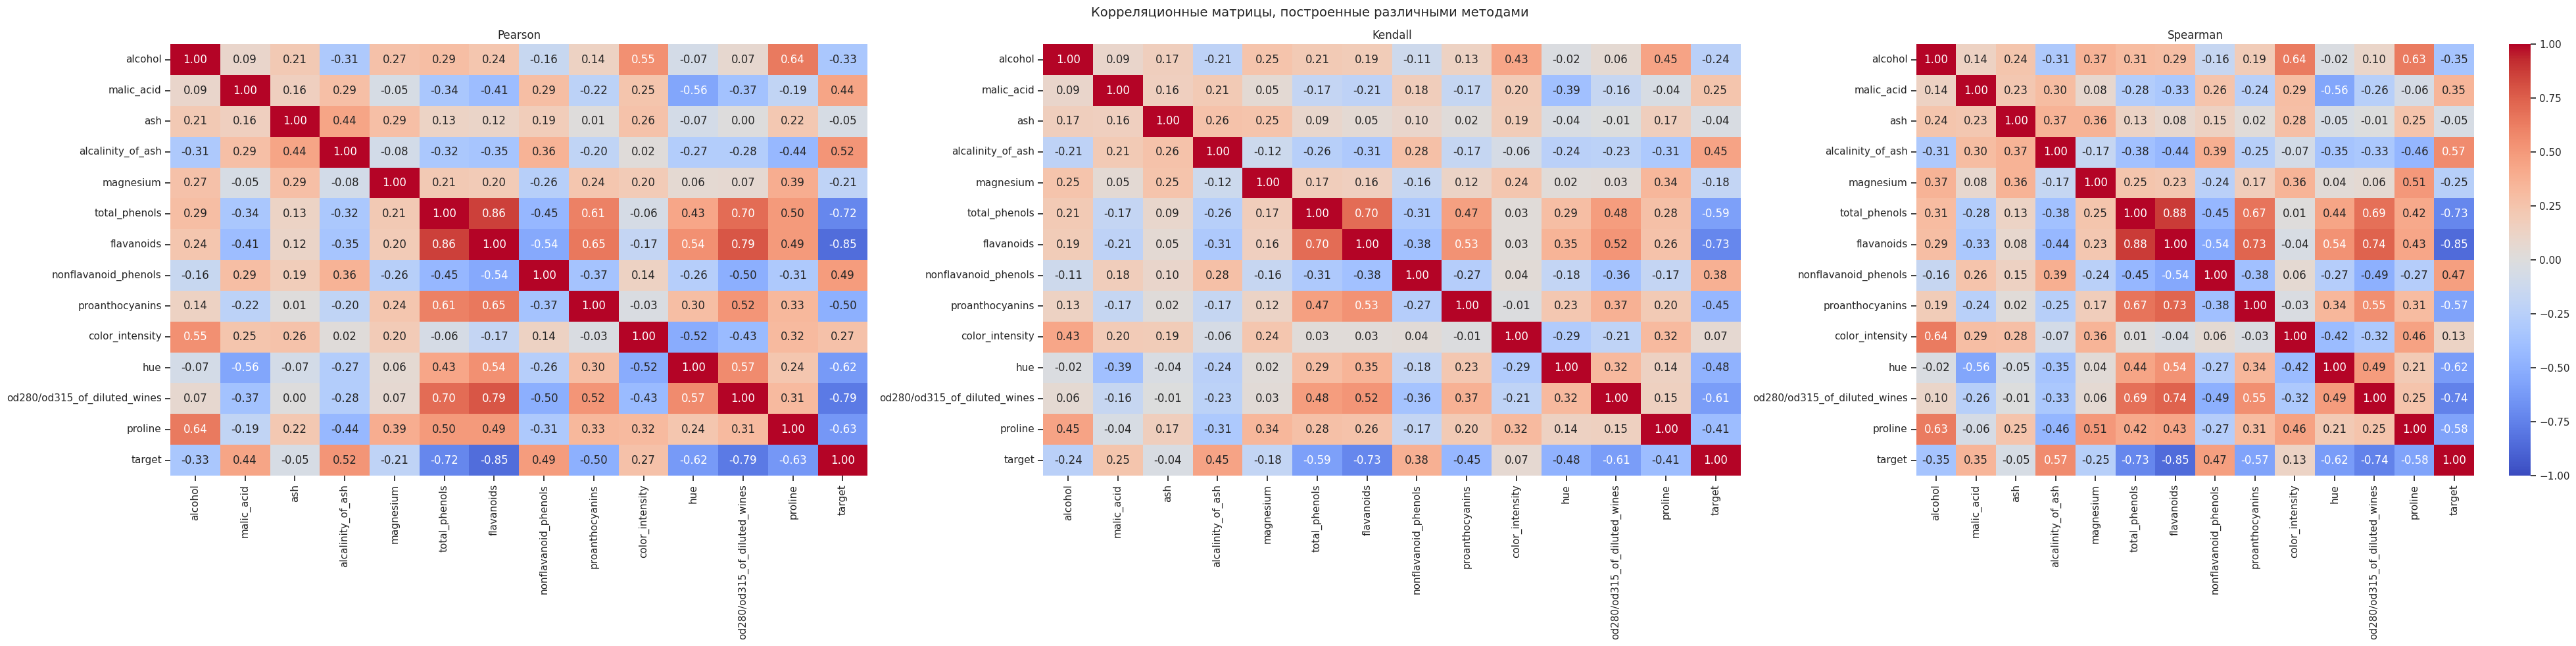

На тепловых картах хорошо видны группы сильно коррелирующих признаков.


In [33]:
# С аннотациями (значениями в ячейках)
fig, ax = plt.subplots(figsize=(14,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Тепловая карта корреляции с аннотациями')
plt.show()

# Треугольный вариант матрицы (верхний треугольник)
# Создаем маску для нижней треугольной части, чтобы оставить верхнюю
mask = np.zeros_like(df.corr(numeric_only=True), dtype=bool)
mask[np.tril_indices_from(mask, k=-1)] = True  # k=-1 исключает диагональ

fig, ax = plt.subplots(figsize=(14,12))
sns.heatmap(df.corr(numeric_only=True), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Треугольная тепловая карта корреляции (верхняя часть)')
plt.show()

# Сравнение различных методов расчета корреляции
fig, axes = plt.subplots(1, 3, figsize=(40,10))
fig.suptitle('Корреляционные матрицы, построенные различными методами', fontsize=14)

# Пирсон
sns.heatmap(df.corr(method='pearson', numeric_only=True), ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', cbar=False, vmin=-1, vmax=1)
axes[0].set_title('Pearson')

# Кендалл
sns.heatmap(df.corr(method='kendall', numeric_only=True), ax=axes[1], annot=True, fmt='.2f',
            cmap='coolwarm', cbar=False, vmin=-1, vmax=1)
axes[1].set_title('Kendall')

# Спирмен
sns.heatmap(df.corr(method='spearman', numeric_only=True), ax=axes[2], annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title('Spearman')

plt.tight_layout()
plt.show()
print("На тепловых картах хорошо видны группы сильно коррелирующих признаков.")

**Общий вывод по корреляции:**

 *   Тепловая карта наглядно подтверждает выводы, сделанные на основе числовой матрицы. Видны темно-синие (сильная отрицательная корреляция с `target`) и ярко-красные (сильная положительная корреляция между признаками) квадраты.
 *   Выявление сильно коррелирующих признаков (мультиколлинеарность) крайне важно для построения некоторых моделей машинного обучения. Для нашего датасета это, например, пара `flavanoids` и `total_phenols`.
 *   Признаки, наиболее сильно коррелирующие с целевой переменной (`flavanoids`, `od280/od315...`, `total_phenols`), будут играть ключевую роль в предсказании класса вина.